# 第 12 章 · 表征搜索与退火代码实验

[章节网页](../ch12.html)

## 运行内容

- 运行 TSP 模拟退火
- 记录路线长度
- 绘制搜索轨迹

## 0. 环境与数据

In [1]:
# 导入实验库，并设置图表中文显示。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display
from scipy.optimize import dual_annealing
from scipy.signal import correlate2d
from sklearn.datasets import load_digits, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# TSP 旅行商问题：用模拟退火交换城市顺序，寻找较短回路。
cities = pd.DataFrame(
    {
        "城市": ["A", "B", "C", "D", "E", "F", "G", "H"],
        "x": [0.1, 0.4, 0.9, 1.4, 1.6, 1.0, 0.5, 0.2],
        "y": [0.2, 0.8, 0.7, 0.3, 1.1, 1.5, 1.4, 1.0],
    }
)
coords = cities[["x", "y"]].to_numpy()

def route_length(route):
    ordered = coords[route]
    closed = np.vstack([ordered, ordered[0]])
    return float(np.linalg.norm(np.diff(closed, axis=0), axis=1).sum())

rng = np.random.default_rng(12)
route = np.arange(len(cities))
rng.shuffle(route)
best_route = route.copy()
best_loss = route_length(route)
current_loss = best_loss
anneal_rows = []

for step in range(1, 401):
    temperature = 1.2 * (0.992 ** step)
    candidate = route.copy()
    i, j = rng.choice(len(route), size=2, replace=False)
    candidate[i], candidate[j] = candidate[j], candidate[i]
    candidate_loss = route_length(candidate)
    accept = candidate_loss < current_loss or rng.random() < np.exp((current_loss - candidate_loss) / max(temperature, 1e-6))
    if accept:
        route = candidate
        current_loss = candidate_loss
    if current_loss < best_loss:
        best_route = route.copy()
        best_loss = current_loss
    if step % 40 == 0:
        anneal_rows.append({"步": step, "温度": temperature, "当前距离": current_loss, "最佳距离": best_loss})

anneal_df = pd.DataFrame(anneal_rows).round(4)
display(cities)
display(anneal_df)
print("best route:", " -> ".join(cities.iloc[best_route]["城市"].tolist()))

,城市,x,y
0,A,0.1,0.2
1,B,0.4,0.8
2,C,0.9,0.7
3,D,1.4,0.3
4,E,1.6,1.1
5,F,1.0,1.5
6,G,0.5,1.4
7,H,0.2,1.0


,步,温度,当前距离,最佳距离
0,40,0.8703,6.6521,6.3545
1,80,0.6311,7.8896,5.5956
2,120,0.4577,5.4351,5.4351
3,160,0.3319,6.7253,5.0930
4,200,0.2407,8.0104,5.0930
5,240,0.1746,6.2185,5.0930
6,280,0.1266,6.2708,5.0930
7,320,0.0918,5.0930,5.0930
8,360,0.0666,5.0930,5.0930
9,400,0.0483,5.0930,5.0930


best route: G -> H -> B -> A -> C -> D -> E -> F


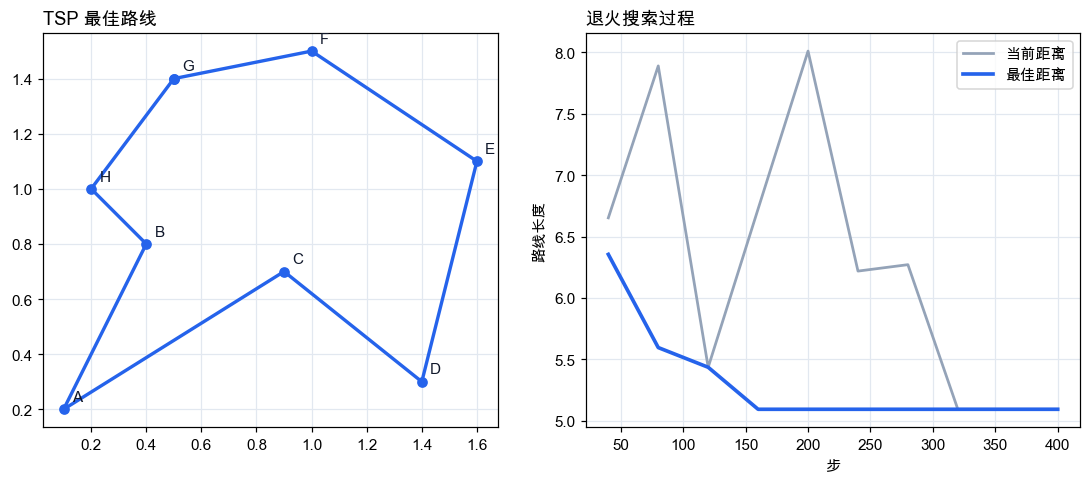

In [3]:
# 绘制 TSP 路线和距离下降。
fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.5))
best_coords = coords[best_route]
closed = np.vstack([best_coords, best_coords[0]])
axes[0].plot(closed[:, 0], closed[:, 1], "-o", color="#2563eb", linewidth=2.2)
for idx, row in cities.iterrows():
    axes[0].text(row["x"] + 0.03, row["y"] + 0.03, row["城市"], color="#0f172a", fontweight="bold")
axes[0].set_title("TSP 最佳路线", loc="left", fontweight="bold")
axes[0].set_aspect("equal", adjustable="box")
axes[0].grid(True, color="#e2e8f0", linewidth=0.8)

axes[1].plot(anneal_df["步"], anneal_df["当前距离"], color="#94a3b8", linewidth=1.8, label="当前距离")
axes[1].plot(anneal_df["步"], anneal_df["最佳距离"], color="#2563eb", linewidth=2.4, label="最佳距离")
axes[1].set_title("退火搜索过程", loc="left", fontweight="bold")
axes[1].set_xlabel("步")
axes[1].set_ylabel("路线长度")
axes[1].grid(True, color="#e2e8f0", linewidth=0.8)
axes[1].legend()
plt.tight_layout()
plt.show()